In [10]:
import numpy as np
import limpy.lline as ll
import limpy.theory as lt

import matplotlib.pyplot as plt
from limpy.plotsettings import *

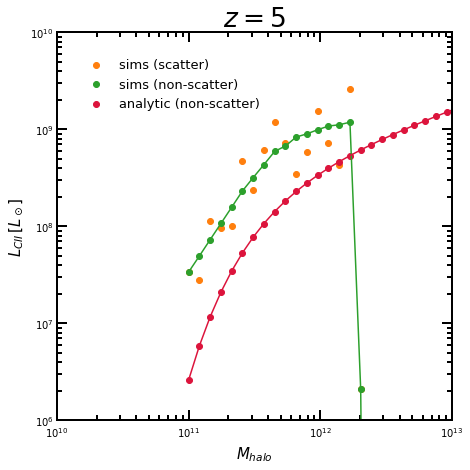

In [11]:
z=np.linspace(3,7,num=20)
#z=np.array(z)
mh=np.logspace(11, 15)
z=5.0
lc2_sim_sca=np.zeros(len(mh))
lc2_sim_mean=np.zeros(len(mh))

lc2_analytic_mean=np.zeros(len(mh))

for i in range(len(mh)):
    lc2_sim_sca[i]=ll.mhalo_to_lline(mh[i], z, use_scatter=True)
    lc2_sim_mean[i]=ll.mhalo_to_lline(mh[i], z, use_scatter=False)
    lc2_analytic_mean[i]=lt.mhalo_to_lcp_fit(mh[i], z)


fig, ax = plt.subplots()
plt.scatter(mh,lc2_sim_sca,color='C1',label=r"sims (scatter)")
plt.scatter(mh, lc2_sim_mean,color='C2', label="sims (non-scatter)")
plt.plot(mh, lc2_sim_mean,color='C2')

plt.scatter(mh, lc2_analytic_mean,color='crimson',label="analytic (non-scatter)")

plt.plot(mh, lc2_analytic_mean,color='crimson')


plt.title(r"$z=5$")
#ax.annotate(r"$M_{h}=10^{11}\, M_\odot$", xy=(3e10, 1e9), xytext=(3e10, 1e9))


plt.xlabel("$M_{halo}$")
plt.ylabel(r"$L_{CII}\,[L_\odot]$")
plt.legend(loc=0,frameon=False)
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e6,1e10)
plt.xlim(1e10,1e13)
plt.tight_layout()
plt.savefig("mhalo_lcp_comparison.png")

In [12]:
# Plot average intensity 
z=np.linspace(0, 8, num=50)
nu_rest_CII=1900 #Ghz
Iav=[lt.I_line(zz,line_name="CII") for zz in z]

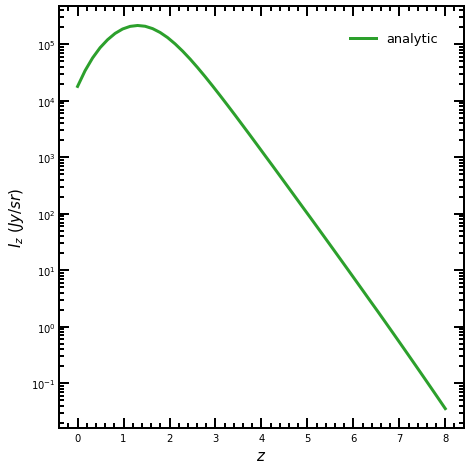

In [13]:
plt.plot(z, Iav, lw=3.0, color='C2', label='analytic')

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$I_z\,\,(Jy/sr)$')
plt.legend(loc=0, frameon=False)
plt.tight_layout()
plt.savefig('intensity.jpg')

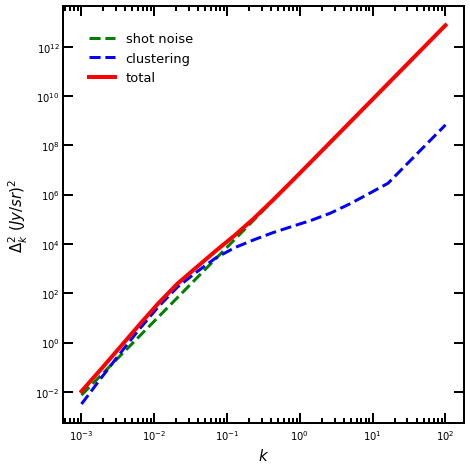

In [14]:
# plot all the power spectra
zline=5.0
nu_rest_line=1900 #GhZ
k=np.logspace(-3, 2, num=20)
pkshot=[lt.Pk_line(kk,zline,label='shot', pk_unit='intensity') for kk in k]
pkclus=[lt.Pk_line(kk,zline,label='clustering', pk_unit='intensity') for kk in k]
pktotal=[lt.Pk_line(kk,zline,label='total', pk_unit='intensity') for kk in k]

plt.plot(k, k**3*pkshot/2.0/np.pi**2, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, k**3*pkclus/2.0/np.pi**2, lw=3, ls='--', color='b',label="clustering")
plt.plot(k, k**3*pktotal/2.0/np.pi**2, lw=4, color='r',label="total")

plt.ylabel(r'$\Delta^2_k\,\,(Jy/sr)^2$')
plt.xlabel(r'$k$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)
plt.tight_layout()
plt.savefig("pk.png")

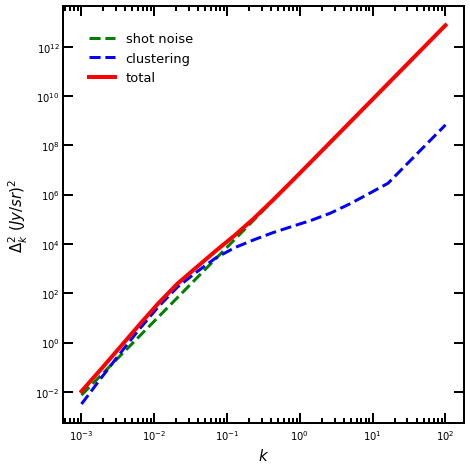

In [20]:
plt.plot(k, k**3*pkshot/2.0/np.pi**2, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, k**3*pkclus/2.0/np.pi**2, lw=3, ls='--', color='b',label="clustering")
plt.plot(k, k**3*pktotal/2.0/np.pi**2, lw=4, color='r',label="total")

#plt.xlim(1e-1*0.7, 1e1*0.7)

plt.ylabel(r'$\Delta^2_k\,\,(Jy/sr)^2$')
plt.xlabel(r'$k$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)
plt.tight_layout()

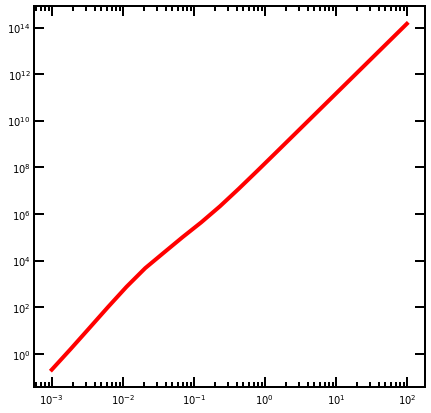

In [22]:
plt.loglog(k, k**3*pktotal, lw=4, color='r',label="total")